# Exploratory Data Analysis (EDA)

## Objective

The purpose of this notebook is to explore the business performance of the Global E-Commerce dataset and discover meaningful insights using descriptive statistics and visualizations.

``Import Libraries``

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

```Load the Dataset```

In [4]:
df = pd.read_csv("../data/raw/ecommerce_dataset_+1m.csv", nrows=10000)
df.head(2)

,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,return_reason,customer_id,customer_name,gender,age,customer_segment,country,city,customer_loyalty_score,total_orders_by_customer,account_creation_date,product_id,product_name,category,sub_category,brand,product_rating_avg,product_reviews_count,stock_quantity,unit_price_usd,quantity,discount_percent,discount_amount_usd,total_price_usd,cost_usd,profit_usd,tax_usd,currency,payment_method,payment_status,installment_plan,shipping_method,shipping_cost_usd,delivery_days,shipping_country,warehouse_location,delivery_status,rating,review_sentiment,customer_feedback,coupon_used,coupon_code,campaign_source,device_type,traffic_source,session_duration_minutes,pages_visited,abandoned_cart_before,fraud_risk_score,profit_margin_percent,order_priority,support_ticket_created
0,ORD-XAJI0,2024-10-14 11:20:05.496679,2024,10,14,11,20,5,No,Completed,NaN,CUS-6DPBH,Drew Warren,Male,53,Regular,Netherlands,Utrecht,22.00,38,2022-04-23,PRD-1FPK,Coffee Maker Automatic,Home,Kitchen,Nike,3.20,3112,99,120.51,3,10,36.15,325.38,232.14,93.24,28.14,USD,Apple Pay,Paid,No,Economy,1.97,5,Netherlands,UK,In Transit,3,Neutral,NaN,Yes,CPN-ZBI,Email,Mobile,Search,52.10,13,No,45.30,28.66,Medium,Yes
1,ORD-NHJ7X,2024-10-21 00:49:44.681065,2024,10,21,0,49,44,No,Completed,NaN,CUS-G0FN9,Victor Sullivan,Male,61,Regular,United States,Los Angeles,82.20,21,2022-08-22,PRD-C6UZ,Yoga Mat Non-Slip,Health,Supplements,Asus,3.80,3758,146,60.33,2,15,18.10,102.56,67.78,34.78,8.96,USD,Bank Transfer,Paid,Yes,Next Day,5.48,3,United States,UK,Delivered,1,Negative,Good value for money,Yes,CPN-W2P,Google Ads,Desktop,Referral,36.20,15,No,97.10,33.91,Low,Yes


```Convert date columns```

In [5]:
date_columns = [
    "order_date",
    "account_creation_date"
]

for column in date_columns:
    df[column] = pd.to_datetime(
        df[column],
        errors="coerce"
    )

In [6]:
df[date_columns].dtypes

order_date               datetime64[us]
account_creation_date    datetime64[us]
dtype: object

## 1. Analysis Dataset Overview

Before starting the business analysis, a short overview is created to confirm the size, date range, and number of unique business entities in the development dataset.


In [7]:
dataset_overview = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Columns",
        "Unique Orders",
        "Unique Customers",
        "Unique Products",
        "First Order Date",
        "Latest Order Date"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df["order_id"].nunique(),
        df["customer_id"].nunique(),
        df["product_id"].nunique(),
        df["order_date"].min(),
        df["order_date"].max()
    ]
})

dataset_overview

,Metric,Value
0,Total Records,10000
1,Total Columns,62
2,Unique Orders,9999
3,Unique Customers,10000
4,Unique Products,9971
5,First Order Date,2024-02-03 05:14:45.982917
6,Latest Order Date,2026-02-02 12:29:16.867113


## 2. Company Performance Overview

This section calculates the main Key Performance Indicators used to understand the overall performance of the e-commerce company.

The analysis compares all records with completed orders because pending, cancelled, processing, and returned orders may not represent successful sales.


In [8]:
df["order_status"].value_counts()

order_status
Completed     6986
Returned       993
Pending        985
Processing     525
Cancelled      511
Name: count, dtype: int64

```Create completed-orders data```

In [9]:
completed_orders = df[
    df["order_status"] == "Completed"
].copy()

In [10]:
print(f"All records: {len(df):,}")
print(f"Completed-order records: {len(completed_orders):,}")

All records: 10,000
Completed-order records: 6,986


```Calculate all-record KPIs```

In [11]:
all_total_revenue = df["total_price_usd"].sum()
all_total_profit = df["profit_usd"].sum()
all_total_orders = df["order_id"].nunique()
all_total_customers = df["customer_id"].nunique()
all_total_products = df["product_id"].nunique()
all_quantity_sold = df["quantity"].sum()

all_average_order_value = (
    all_total_revenue / all_total_orders
)

all_profit_margin = (
    all_total_profit / all_total_revenue
) * 100

```Calculate completed-order KPIs```

In [12]:
completed_total_revenue = completed_orders["total_price_usd"].sum()
completed_total_profit = completed_orders["profit_usd"].sum()
completed_total_orders = completed_orders["order_id"].nunique()
completed_total_customers = completed_orders["customer_id"].nunique()
completed_total_products = completed_orders["product_id"].nunique()
completed_quantity_sold = completed_orders["quantity"].sum()

completed_average_order_value = (
    completed_total_revenue / completed_total_orders
)

completed_profit_margin = (
    completed_total_profit / completed_total_revenue
) * 100

```Display company KPIs```


In [13]:
print("COMPANY PERFORMANCE — COMPLETED ORDERS")
print("-" * 50)

print(f"Total Revenue       : ${completed_total_revenue:,.2f}")
print(f"Total Profit        : ${completed_total_profit:,.2f}")
print(f"Total Orders        : {completed_total_orders:,}")
print(f"Total Customers     : {completed_total_customers:,}")
print(f"Unique Products     : {completed_total_products:,}")
print(f"Quantity Sold       : {completed_quantity_sold:,}")
print(f"Average Order Value : ${completed_average_order_value:,.2f}")
print(f"Profit Margin       : {completed_profit_margin:.2f}%")

COMPANY PERFORMANCE — COMPLETED ORDERS
--------------------------------------------------
Total Revenue       : $2,847,239.12
Total Profit        : $1,136,468.29
Total Orders        : 6,985
Total Customers     : 6,986
Unique Products     : 6,971
Quantity Sold       : 20,861
Average Order Value : $407.62
Profit Margin       : 39.91%


```Create a KPI comparison table```


In [14]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Unique Products",
        "Quantity Sold",
        "Average Order Value",
        "Profit Margin"
    ],
    "All Records": [
        all_total_revenue,
        all_total_profit,
        all_total_orders,
        all_total_customers,
        all_total_products,
        all_quantity_sold,
        all_average_order_value,
        all_profit_margin
    ],
    "Completed Orders": [
        completed_total_revenue,
        completed_total_profit,
        completed_total_orders,
        completed_total_customers,
        completed_total_products,
        completed_quantity_sold,
        completed_average_order_value,
        completed_profit_margin
    ]
})

kpi_summary

,KPI,All Records,Completed Orders
0,Total Revenue,"4,055,773.24","2,847,239.12"
1,Total Profit,"1,624,669.98","1,136,468.29"
2,Total Orders,"9,999.00","6,985.00"
3,Total Customers,"10,000.00","6,986.00"
4,Unique Products,"9,971.00","6,971.00"
5,Quantity Sold,"29,841.00","20,861.00"
6,Average Order Value,405.62,407.62
7,Profit Margin,40.06,39.91


```Calculate completion rate```


In [15]:
order_completion_rate = (
    completed_total_orders / all_total_orders
) * 100

print(f"Order Completion Rate: {order_completion_rate:.2f}%")

Order Completion Rate: 69.86%


```Order-status summary table```


In [16]:
order_status_summary = (
    df["order_status"]
    .value_counts()
    .rename_axis("Order Status")
    .reset_index(name="Number of Records")
)

order_status_summary["Percentage"] = (
    order_status_summary["Number of Records"]
    / order_status_summary["Number of Records"].sum()
    * 100
).round(2)

order_status_summary

,Order Status,Number of Records,Percentage
0,Completed,6986,69.86
1,Returned,993,9.93
2,Pending,985,9.85
3,Processing,525,5.25
4,Cancelled,511,5.11


```Visualize order statuses```


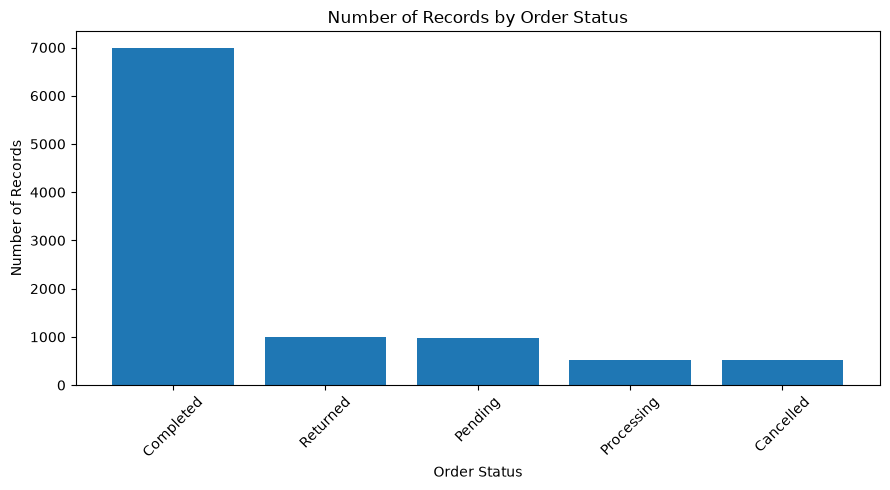

In [17]:
order_status_counts = df["order_status"].value_counts()

plt.figure(figsize=(9, 5))

plt.bar(
    order_status_counts.index,
    order_status_counts.values
)

plt.title("Number of Records by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/order_status_distribution.png")
plt.show()

### Business Observation

Completed orders represent approximately **69.86%** of all orders in the development sample.

The completed-order KPIs were used as the primary measure of business performance because cancelled, returned, pending, and processing orders do not necessarily represent successful sales.

The comparison between all records and completed orders highlights the importance of filtering data based on order status before calculating key business metrics such as revenue, profit, and average order value.

# 3. Sales Performance Analysis

The objective of this section is to evaluate the company's sales performance across different product categories. The analysis focuses on revenue, profitability, quantity sold, discounts, and customer ratings to identify high-performing and underperforming business segments.

In [18]:
df['category'].value_counts()

category
Health         2057
Clothing       2056
Electronics    1996
Sports         1974
Home           1917
Name: count, dtype: int64

```Which product category generates the highest revenue?```

In [19]:
category_revenue = (
    completed_orders.groupby("category")["total_price_usd"].sum().sort_values(ascending=False)
)

category_revenue

category
Electronics   993,305.34
Home          604,159.45
Sports        502,932.13
Health        409,496.35
Clothing      337,345.85
Name: total_price_usd, dtype: float64

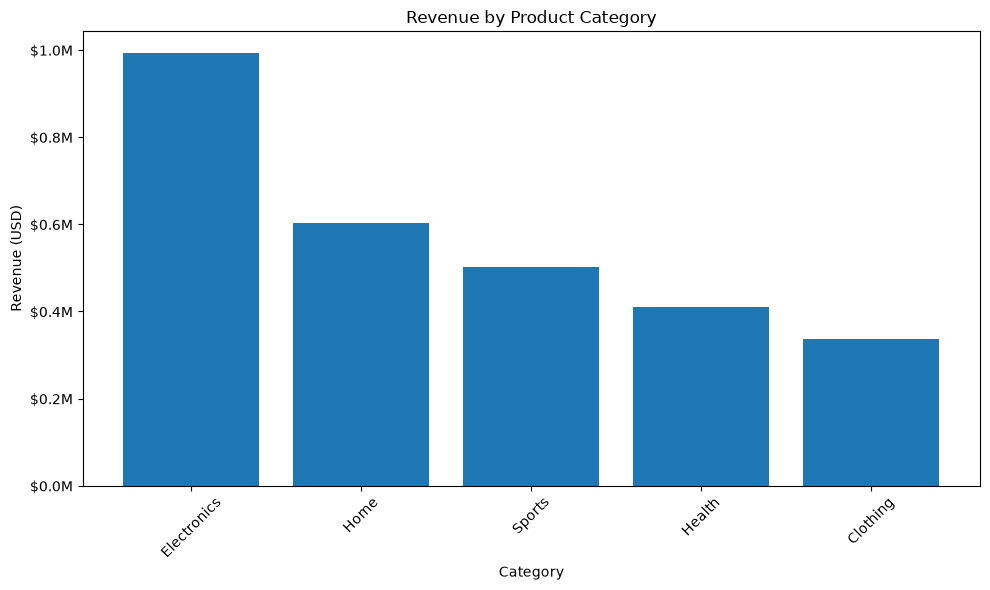

In [41]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))

plt.bar(
    category_revenue.index,
    category_revenue.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"${value / 1_000_000:.1f}M")
)

plt.tight_layout()
plt.savefig("../images/category_revenue.png")
plt.show()

### Revenue Insight

Electronics generated the highest revenue among all product categories, contributing significantly more revenue than the remaining categories.

Although Electronics did not sell the highest number of units, its strong revenue performance suggests that products in this category have a higher average selling price.

```Which category generates the highest profit?```

In [23]:
category_profit = (
    completed_orders.groupby("category")["profit_usd"].sum().sort_values(ascending=False)
)
category_profit


category
Electronics   395,753.88
Home          243,418.92
Sports        202,336.90
Health        159,985.82
Clothing      134,972.77
Name: profit_usd, dtype: float64

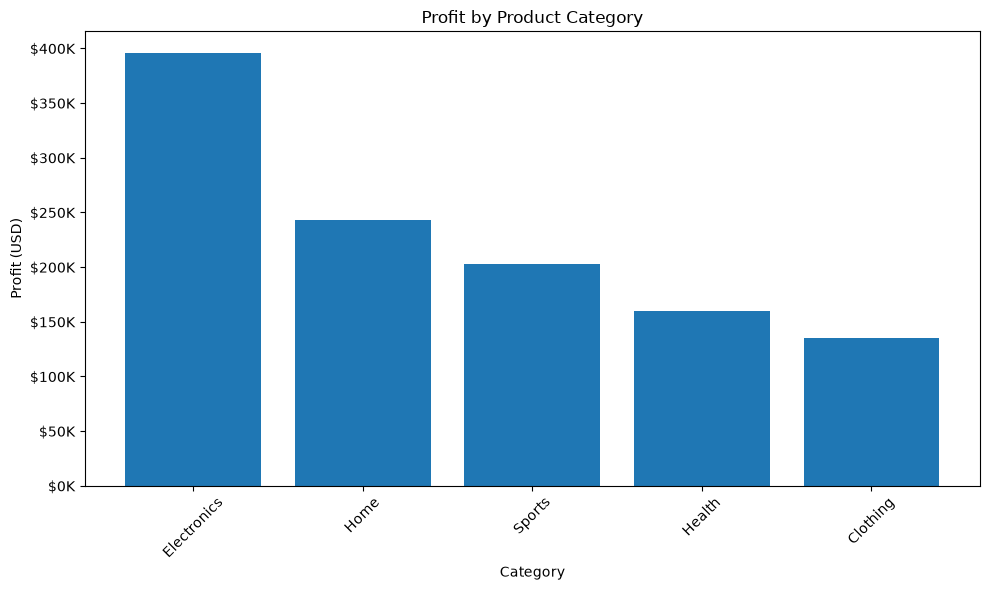

In [42]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))

plt.bar(
    category_profit.index,
    category_profit.values
)

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit (USD)")
plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"${value / 1_000:.0f}K")
)

plt.tight_layout()
plt.savefig("../images/category_profit.png")
plt.show()

### Profit Insight

Electronics generated the highest total profit, followed by Home and Sports.

The similarity between the revenue and profit rankings indicates that Electronics is not only the largest revenue contributor but also one of the most financially valuable categories for the business.

```Which category sells the most units?```

In [27]:
category_quantity = (
    completed_orders.groupby("category")["quantity"].sum().sort_values(ascending=False)
)
category_quantity

category
Clothing       4351
Health         4207
Electronics    4147
Sports         4082
Home           4074
Name: quantity, dtype: int64

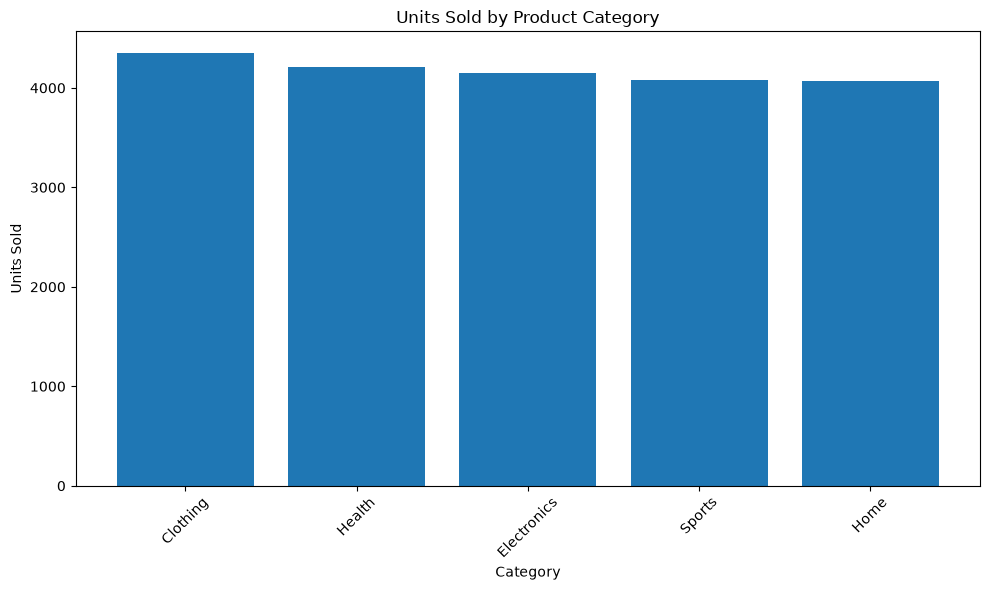

In [28]:
plt.figure(figsize=(10,6))
plt.bar(
    category_quantity.index,
    category_quantity.values
)

plt.title("Units Sold by Product Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/category_quantity.png")
plt.show()

### Quantity Sold Insight

Clothing recorded the highest number of units sold, despite generating the lowest revenue among the categories.

This indicates that Clothing products are likely lower-priced items, while Electronics generates substantially more revenue from a similar or lower sales volume.

```Which category gives the highest total discounts?```

In [29]:
category_discount = (
    completed_orders.groupby("category")["discount_amount_usd"].sum().sort_values(ascending=False)
    )
    
category_discount

category
Electronics   97,903.16
Home          55,453.08
Sports        43,833.90
Health        39,482.97
Clothing      29,838.26
Name: discount_amount_usd, dtype: float64

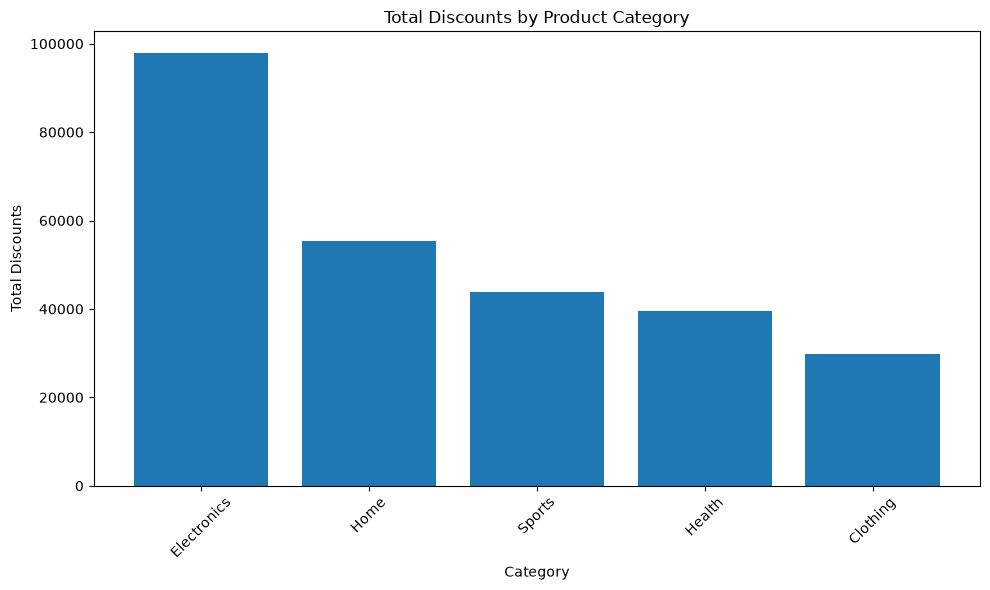

In [30]:
plt.figure(figsize=(10,6))
plt.bar(
    category_discount.index,
    category_discount.values
)

plt.title("Total Discounts by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Discounts")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/category_discount.png")
plt.show()


### Discount Insight

Electronics received the highest total discount amount among all categories.

However, because Electronics also generated the highest revenue, the larger discount total may be influenced by its higher product prices and sales value. A discount-rate analysis is required before concluding that Electronics is being over-discounted.

```Which category has the highest average customer rating?```


In [31]:
category_rating = (
    completed_orders.groupby("category")["rating"].mean().sort_values(ascending=False)
)
category_rating


category
Health        3.01
Sports        3.00
Electronics   2.99
Home          2.97
Clothing      2.96
Name: rating, dtype: float64

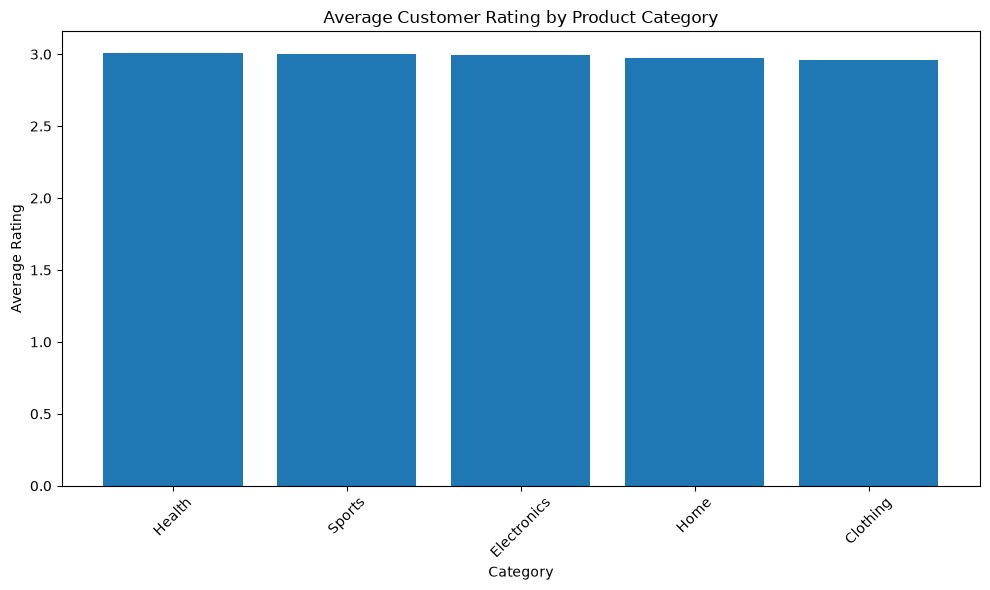

In [32]:
plt.figure(figsize=(10,6))
plt.bar(
    category_rating.index,
    category_rating.values
)

plt.title("Average Customer Rating by Product Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/category_rating.png")
plt.show()


### Customer Rating Insight

Average customer ratings were close to 3 out of 5 across all product categories, with only minor differences between them.

No category demonstrated a clearly superior customer satisfaction level. The consistently moderate ratings may indicate opportunities to improve product quality, delivery experience, or after-sales service across the business.

```Which category has the highest profit margin?```


In [34]:
category_margin = (
completed_orders.groupby("category").agg({
    "profit_usd": "sum",
    "total_price_usd": "sum",
    })
)

category_margin["profit_margin"] = (category_margin["profit_usd"] / category_margin["total_price_usd"])*100

category_margin = category_margin.sort_values(by="profit_margin", ascending=False)
category_margin


,profit_usd,total_price_usd,profit_margin
category,,,
Home,"243,418.92","604,159.45",40.29
Sports,"202,336.90","502,932.13",40.23
Clothing,"134,972.77","337,345.85",40.01
Electronics,"395,753.88","993,305.34",39.84
Health,"159,985.82","409,496.35",39.07


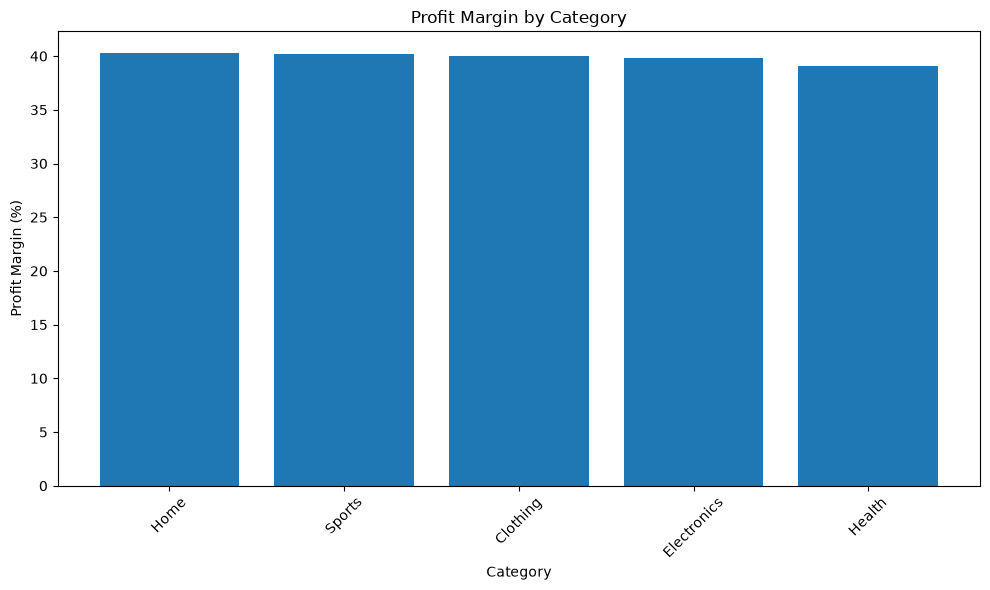

In [35]:
plt.figure(figsize=(10,6))

plt.bar(
    category_margin.index,
    category_margin["profit_margin"]
)

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/profit_margin_by_category.png")
plt.show()

### Profit Margin Insight

Profit margins remained close to 40% across all product categories, indicating relatively consistent profitability.

Home recorded the highest margin, while Health recorded the lowest. However, the difference was small, so there is no major category-level profitability gap in the current sample.

### Overall Category Performance Summary

Electronics is the strongest category in terms of both revenue and total profit, despite not having the highest sales volume. This suggests that its performance is driven mainly by higher-value products.

Clothing recorded the highest number of units sold but the lowest revenue and profit, indicating a lower average selling price per item.

Customer ratings and profit margins were relatively similar across categories. Therefore, the major difference in category performance appears to come from product pricing and total transaction value rather than major differences in customer satisfaction or profitability percentage.

```Average selling price per unit by product category```


In [38]:
category_average_price = (
    completed_orders
    .groupby("category")
    .agg(
        revenue=("total_price_usd", "sum"),
        units_sold=("quantity", "sum")
    )
)

category_average_price["average_revenue_per_unit"] = (
    category_average_price["revenue"]
    / category_average_price["units_sold"]
)

category_average_price = category_average_price.sort_values(
    "average_revenue_per_unit",
    ascending=False
)

category_average_price

,revenue,units_sold,average_revenue_per_unit
category,,,
Electronics,"993,305.34",4147,239.52
Home,"604,159.45",4074,148.30
Sports,"502,932.13",4082,123.21
Health,"409,496.35",4207,97.34
Clothing,"337,345.85",4351,77.53


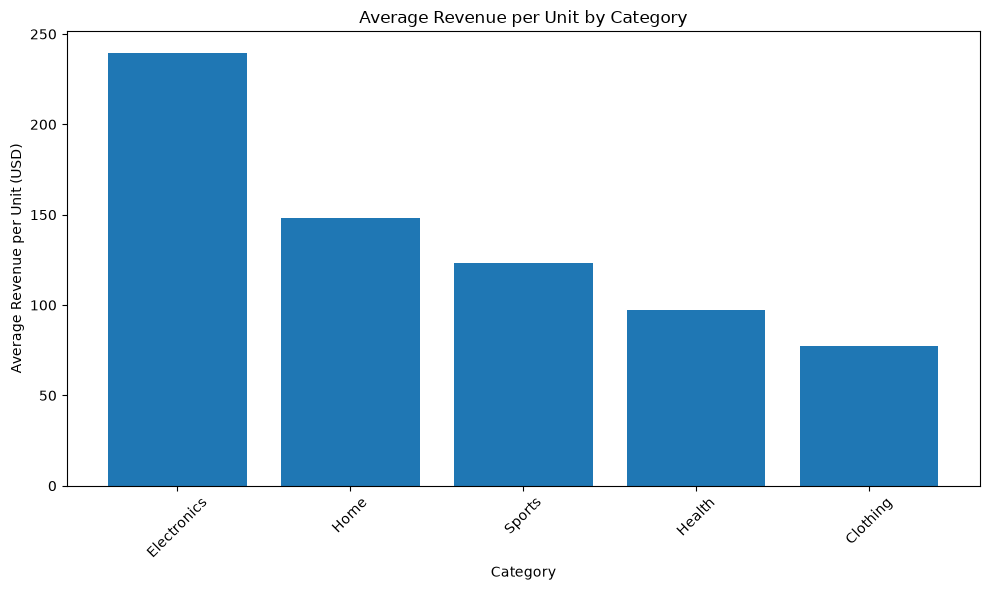

In [40]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_average_price.index,
    category_average_price["average_revenue_per_unit"]
)

plt.title("Average Revenue per Unit by Category")
plt.xlabel("Category")
plt.ylabel("Average Revenue per Unit (USD)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/category_average_price.png")
plt.show()

# 4. Product Performance Analysis

The objective of this section is to identify the best-performing and worst-performing products based on revenue, profit, sales volume, customer ratings, and profitability.

Understanding product-level performance helps businesses optimize inventory, pricing strategies, and marketing efforts.

```Which products generate the highest revenue?```


In [43]:
top_products_revenue = (
    completed_orders
    .groupby("product_name")["total_price_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

product_name
Gaming Mechanical Keyboard RGB    92,249.30
Wireless Mouse 2.4GHz             90,222.66
Portable SSD 1TB                  87,129.04
Laptop Backpack Waterproof        86,469.60
Screen Protector Tempered Glass   85,717.35
USB Hub 7-Port                    85,342.99
4K Webcam Pro                     80,705.41
Wireless Bluetooth Earbuds        80,459.34
Smart Watch Series 8              78,683.88
USB-C Fast Charger 65W            77,845.85
Name: total_price_usd, dtype: float64

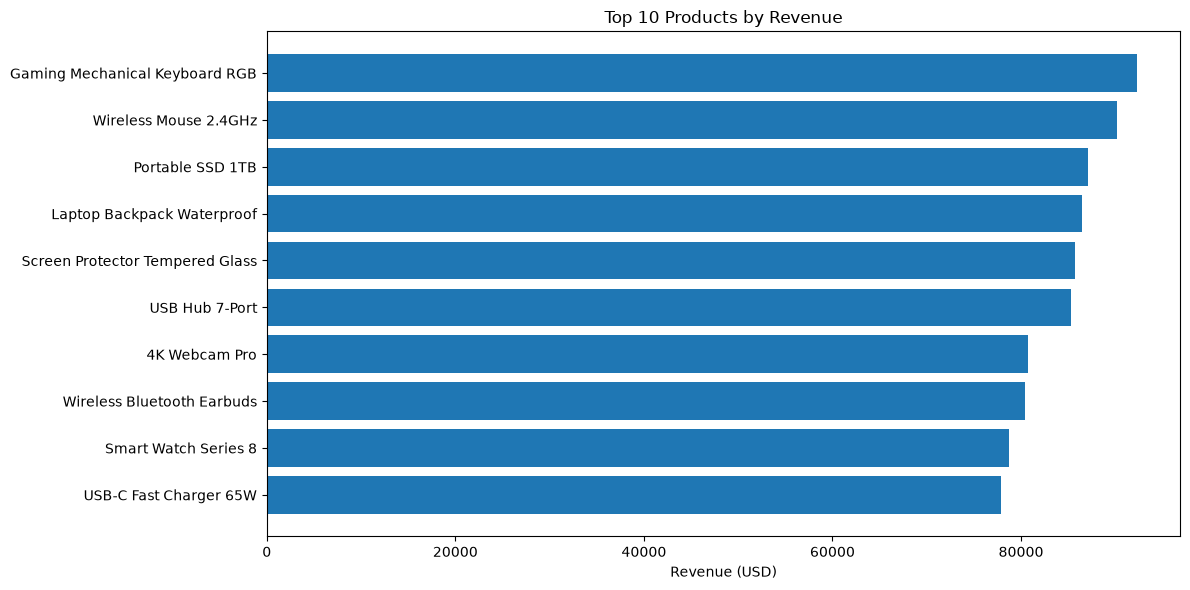

In [44]:
plt.figure(figsize=(12,6))

plt.barh(
    top_products_revenue.index[::-1],
    top_products_revenue.values[::-1]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (USD)")
plt.tight_layout()
plt.savefig("../images/top_products_revenue.png")
plt.show()

In [56]:
completed_orders.groupby("product_name")


In [58]:
completed_orders["product_name"].nunique()

48

```Which products generate the highest profit?```

In [45]:
top_products_profit = (
    completed_orders
    .groupby("product_name")["profit_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_profit

product_name
Gaming Mechanical Keyboard RGB    36,109.38
Wireless Mouse 2.4GHz             36,100.88
Laptop Backpack Waterproof        34,774.25
USB Hub 7-Port                    34,419.38
Portable SSD 1TB                  34,373.25
Screen Protector Tempered Glass   33,360.34
USB-C Fast Charger 65W            32,732.07
Wireless Bluetooth Earbuds        32,280.69
Smart Watch Series 8              31,596.05
4K Webcam Pro                     31,339.52
Name: profit_usd, dtype: float64

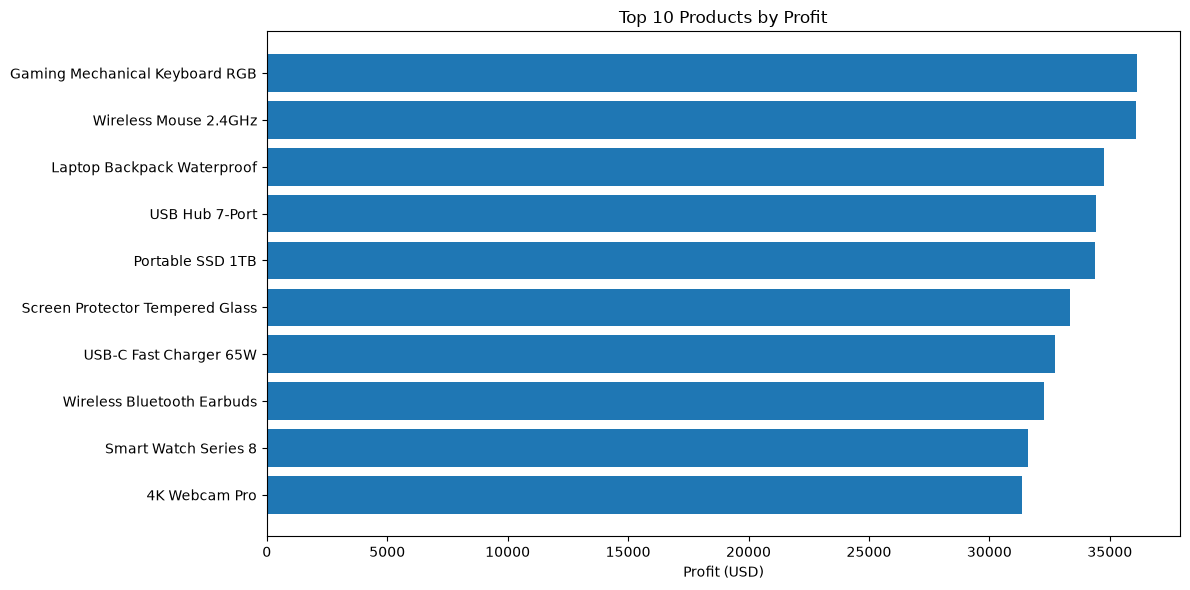

In [46]:
plt.figure(figsize=(12,6))
plt.barh(
    top_products_profit.index[::-1],
    top_products_profit.values[::-1]
)

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit (USD)")
plt.tight_layout()
plt.savefig("../images/top_products_profit.png")
plt.show()


```Which products sell the most units?```


In [47]:
top_products_quantity = (
    completed_orders
    .groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity

product_name
Yoga Pants Leggings               540
Digital Blood Pressure Monitor    528
Baseball Cap                      521
Running Shoes Air Zoom            517
Massage Gun Deep Tissue           512
Sports Bra High Impact            511
Denim Jeans Slim Fit              497
Water Bottle Insulated            488
Yoga Mat Non-Slip                 485
LED Strip Lights 5m               482
Name: quantity, dtype: int64

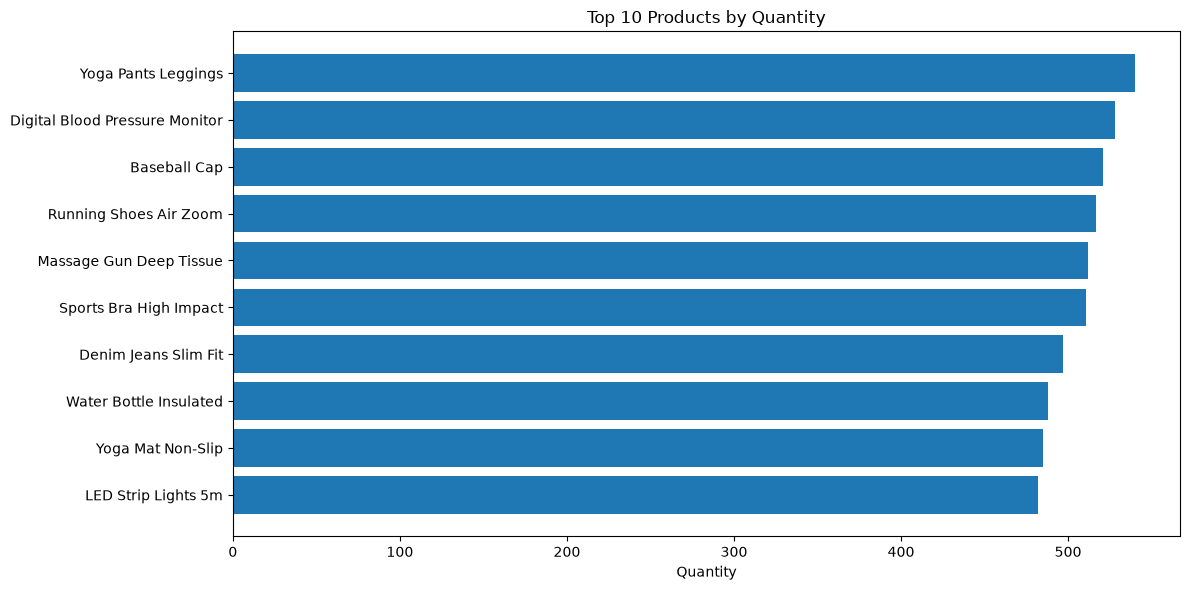

In [48]:
plt.figure(figsize=(12,6))
plt.barh(
    top_products_quantity.index[::-1],
    top_products_quantity.values[::-1]
)
plt.title("Top 10 Products by Quantity")
plt.xlabel("Quantity")
plt.tight_layout()
plt.savefig("../images/top_products_quantity.png")
plt.show()


```Which products have the highest average customer rating?```


In [49]:
top_products_rating = (
    completed_orders
    .groupby("product_name")["rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_products_rating

product_name
Cotton T-Shirt Pack          3.24
Portable SSD 1TB             3.20
Water Bottle Insulated       3.20
Wireless Bluetooth Earbuds   3.19
Storage Box Set              3.17
Massage Gun Deep Tissue      3.16
Blender 1000W                3.16
Wireless Mouse 2.4GHz        3.15
Badminton Racket             3.10
Digital Thermometer          3.10
Name: rating, dtype: float64

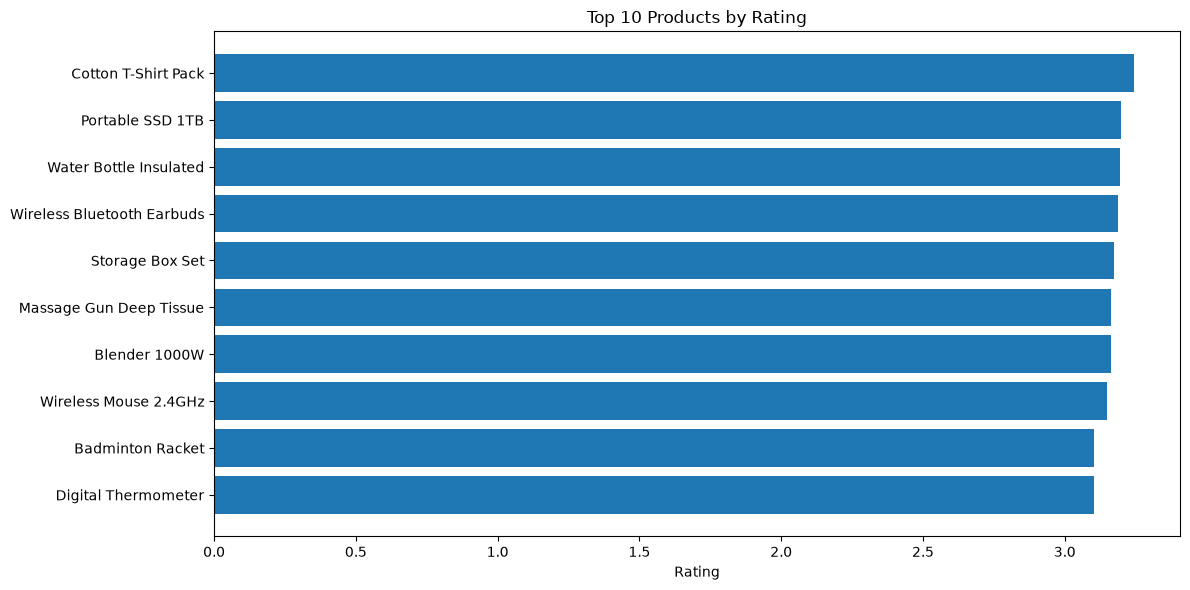

In [50]:
plt.figure(figsize=(12,6))
plt.barh(
    top_products_rating.index[::-1],
    top_products_rating.values[::-1]
)
plt.title("Top 10 Products by Rating")
plt.xlabel("Rating")
plt.tight_layout()
plt.savefig("../images/top_products_rating.png")
plt.show()


```Which products have the highest profit margin?```


In [51]:
product_margin = (
    completed_orders
    .groupby("product_name")
    .agg({
        "profit_usd":"sum",
        "total_price_usd":"sum"
    })
)

product_margin["profit_margin"] = (
    product_margin["profit_usd"]
    / product_margin["total_price_usd"]
) * 100

top_margin_products = (
    product_margin
    .sort_values("profit_margin", ascending=False)
    .head(10)
)

top_margin_products

,profit_usd,total_price_usd,profit_margin
product_name,,,
USB-C Fast Charger 65W,"32,732.07","77,845.85",42.05
Bedsheet Set Cotton,"30,313.87","72,457.05",41.84
Dumbbells Set Adjustable,"23,564.78","56,694.94",41.56
Swimming Goggles,"20,151.01","48,501.33",41.55
LED Strip Lights 5m,"30,683.52","74,260.00",41.32
Vacuum Robot Cleaner,"26,910.58","65,385.71",41.16
Winter Jacket Waterproof,"14,426.23","35,166.90",41.02
Hooded Sweatshirt,"12,918.42","31,551.32",40.94
Badminton Racket,"21,691.06","53,178.44",40.79


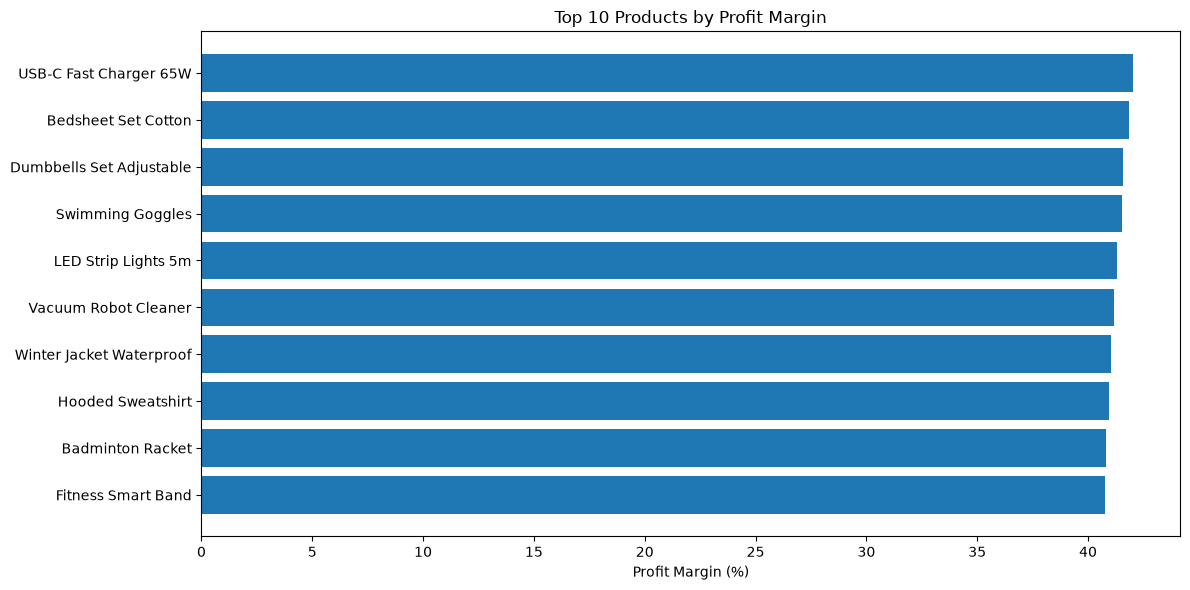

In [52]:
plt.figure(figsize=(12,6))

plt.barh(
    top_margin_products.index[::-1],
    top_margin_products["profit_margin"].values[::-1]
)
plt.title("Top 10 Products by Profit Margin")
plt.xlabel("Profit Margin (%)")
plt.tight_layout()
plt.savefig("../images/top_margin_products.png")
plt.show()


# 6. Time-Series Analysis

This section analyzes sales and profit trends over time to identify growth patterns, seasonal effects, and periods of strong or weak business performance.

```How does monthly revenue change over time?```

In [60]:
completed_orders["year_month"] = (
    completed_orders["order_date"]
    .dt.to_period("M")
    .astype(str)
)

In [61]:
monthly_revenue = (
    completed_orders
    .groupby("year_month")["total_price_usd"]
    .sum()
)

monthly_revenue

year_month
2024-02   118,640.96
2024-03   108,371.02
2024-04   141,724.47
2024-05   113,792.23
2024-06   109,360.03
2024-07   131,095.65
2024-08   117,269.50
2024-09   121,812.02
2024-10   128,662.60
2024-11    99,404.74
2024-12   116,291.58
2025-01   118,701.66
2025-02   100,592.00
2025-03   109,994.41
2025-04    99,358.34
2025-05   137,239.44
2025-06   106,464.33
2025-07   124,712.57
2025-08   118,195.39
2025-09   128,354.78
2025-10   129,921.94
2025-11   110,871.06
2025-12   135,177.37
2026-01   117,809.77
2026-02     3,421.26
Name: total_price_usd, dtype: float64

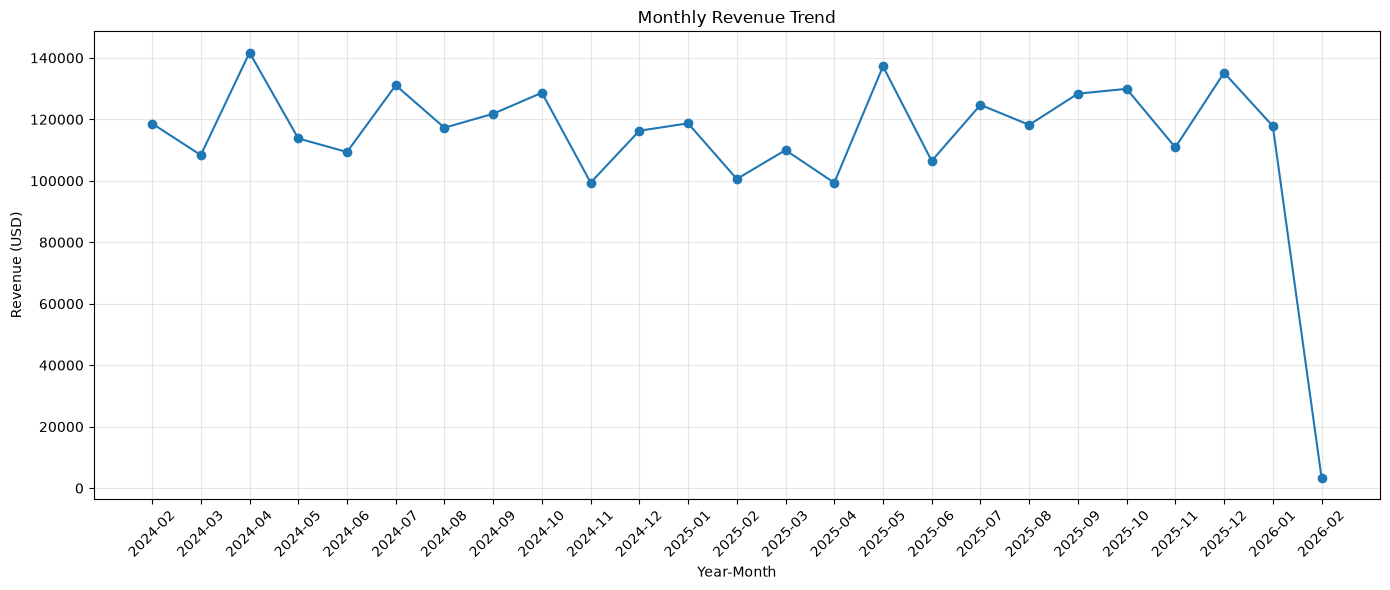

In [62]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../images/monthly_revenue_trend.png", dpi=300)
plt.show()

### Revenue Trend Insight

Monthly revenue remained relatively stable throughout the analysis period, generally ranging between $100K and $140K.

Several months experienced noticeable revenue peaks, particularly April 2024, May 2025, and December 2025. The sharp decline observed in February 2026 is likely due to incomplete monthly data rather than an actual reduction in business performance.

```How does monthly profit change?```

In [63]:
monthly_profit = (
    completed_orders
    .groupby("year_month")["profit_usd"]
    .sum()
)

monthly_profit

year_month
2024-02   46,662.09
2024-03   43,536.48
2024-04   56,193.46
2024-05   46,069.90
2024-06   43,749.56
2024-07   51,333.61
2024-08   47,636.36
2024-09   49,712.20
2024-10   50,611.72
2024-11   39,620.45
2024-12   44,883.89
2025-01   47,042.32
2025-02   41,117.00
2025-03   44,022.56
2025-04   41,117.12
2025-05   53,397.97
2025-06   42,605.60
2025-07   48,862.00
2025-08   49,005.80
2025-09   50,682.06
2025-10   50,045.40
2025-11   44,976.95
2025-12   54,185.12
2026-01   48,118.28
2026-02    1,280.39
Name: profit_usd, dtype: float64

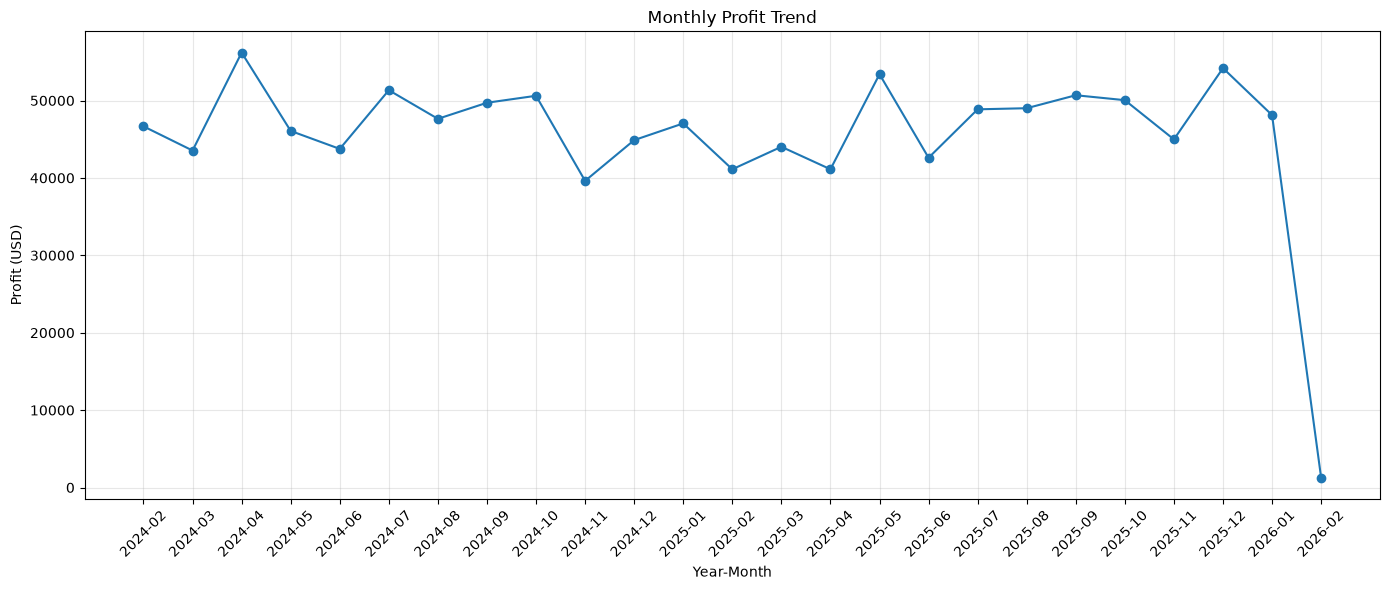

In [64]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Year-Month")
plt.ylabel("Profit (USD)")
plt.xticks(rotation=45)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../images/monthly_profit_trend.png", dpi=300)
plt.show()

### Profit Trend Insight

Monthly profit closely followed the revenue trend, indicating a consistent relationship between sales and profitability.

Months with higher revenue also generated higher profits, suggesting stable profit margins across the analysis period.

```How many completed orders occur each month?```


In [65]:
monthly_orders = (
    completed_orders
    .groupby("year_month")["order_id"]
    .count()
)

monthly_orders

year_month
2024-02    274
2024-03    276
2024-04    332
2024-05    270
2024-06    284
2024-07    294
2024-08    288
2024-09    297
2024-10    311
2024-11    254
2024-12    286
2025-01    305
2025-02    255
2025-03    288
2025-04    267
2025-05    319
2025-06    282
2025-07    301
2025-08    277
2025-09    297
2025-10    323
2025-11    281
2025-12    323
2026-01    292
2026-02     10
Name: order_id, dtype: int64

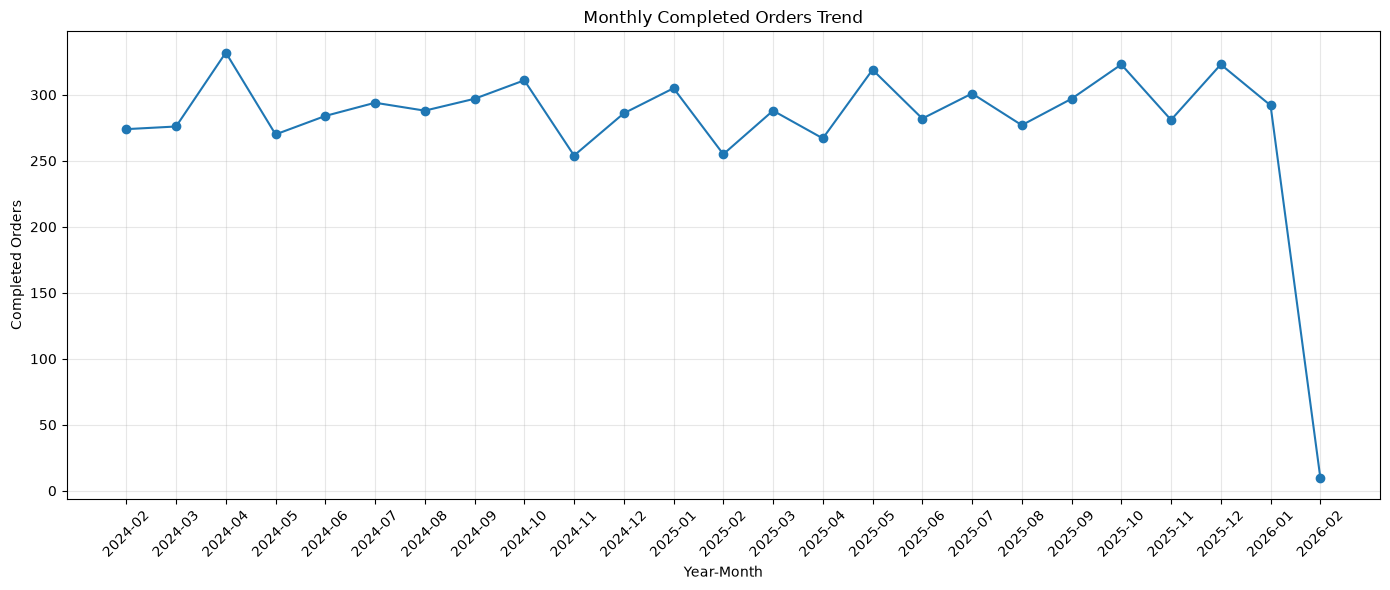

In [66]:
plt.figure(figsize=(14,6))
plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker="o"
)
plt.title("Monthly Completed Orders Trend")
plt.xlabel("Year-Month")
plt.ylabel("Completed Orders")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../images/monthly_completed_orders_trend.png", dpi=300)
plt.show()

```Average Order Value by Month```


In [67]:
monthly_aov = (
    completed_orders
    .groupby("year_month")["total_price_usd"]
    .mean()
)

monthly_aov

year_month
2024-02   433.00
2024-03   392.65
2024-04   426.88
2024-05   421.45
2024-06   385.07
2024-07   445.90
2024-08   407.19
2024-09   410.14
2024-10   413.71
2024-11   391.36
2024-12   406.61
2025-01   389.19
2025-02   394.48
2025-03   381.93
2025-04   372.13
2025-05   430.22
2025-06   377.53
2025-07   414.33
2025-08   426.70
2025-09   432.17
2025-10   402.24
2025-11   394.56
2025-12   418.51
2026-01   403.46
2026-02   342.13
Name: total_price_usd, dtype: float64

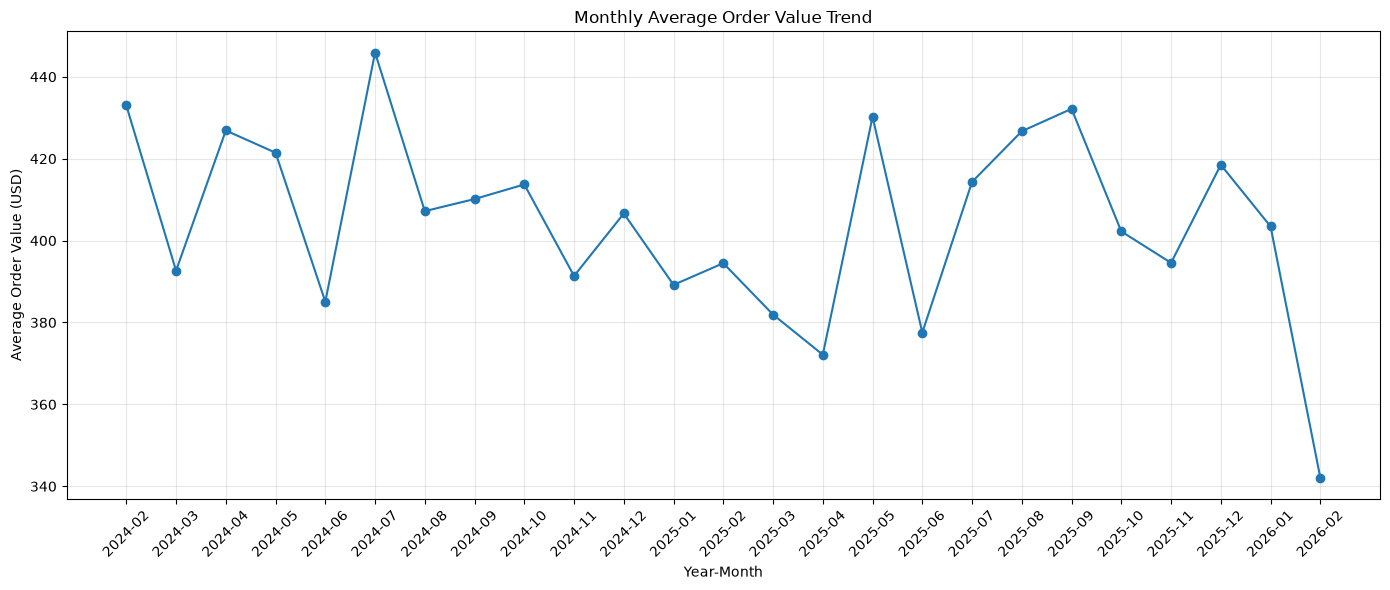

In [68]:
plt.figure(figsize=(14,6))
plt.plot(
    monthly_aov.index,
    monthly_aov.values,
    marker="o"
)
plt.title("Monthly Average Order Value Trend")
plt.xlabel("Year-Month")
plt.ylabel("Average Order Value (USD)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../images/monthly_average_order_value_trend.png", dpi=300)
plt.show()

## Time-Series Summary

The business maintained relatively stable monthly performance throughout the analysis period. Revenue, profit, and completed orders showed only moderate fluctuations without a sustained upward or downward trend.

Revenue and profit moved closely together, indicating consistent profitability across the months. Average Order Value also remained relatively stable, suggesting that customer spending behavior changed very little during the observed period.

The unusually low values in February 2026 were excluded from interpretation because they likely represent an incomplete reporting month.

# 7. Customer Analysis

The objective of this section is to understand customer purchasing behaviour by analyzing customer segments, demographics, loyalty, and spending patterns.

These insights can help businesses identify their most valuable customers and improve marketing strategies.

```Which customer segment generates the highest revenue?```

In [69]:
segment_revenue = (
    completed_orders
    .groupby("customer_segment")["total_price_usd"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

customer_segment
Regular   1,730,983.10
Premium     839,406.39
VIP         276,849.63
Name: total_price_usd, dtype: float64

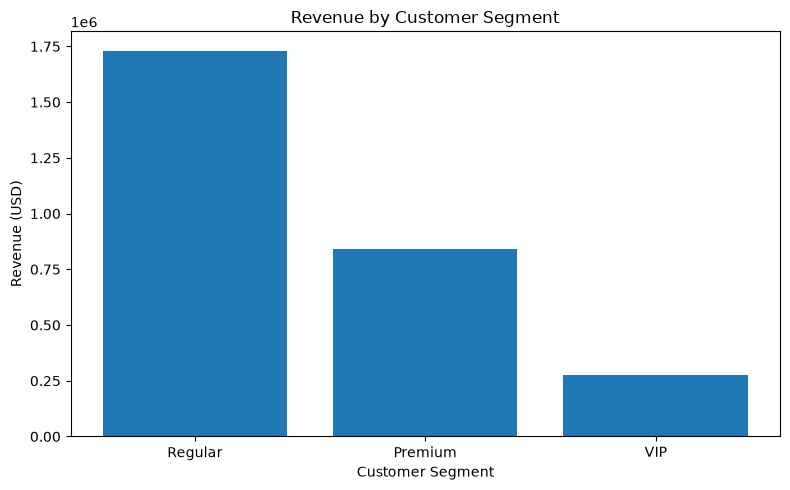

In [70]:
plt.figure(figsize=(8,5))

plt.bar(
    segment_revenue.index,
    segment_revenue.values
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue (USD)")

plt.tight_layout()
plt.savefig("../images/segment_revenue.png")
plt.show()

### Revenue by Customer Segment

Regular customers generated the highest total revenue, followed by Premium and VIP customers.

Although VIP customers may spend more per purchase, the Regular segment contributes the largest share of revenue, likely because it represents the largest customer group. This suggests that retaining Regular customers is critical for maintaining overall sales performance.

```Which customer segment generates the highest profit?```


In [71]:
segment_profit = (
    completed_orders
    .groupby("customer_segment")["profit_usd"]
    .sum()
    .sort_values(ascending=False)
)

segment_profit

customer_segment
Regular   692,494.97
Premium   333,505.54
VIP       110,467.78
Name: profit_usd, dtype: float64

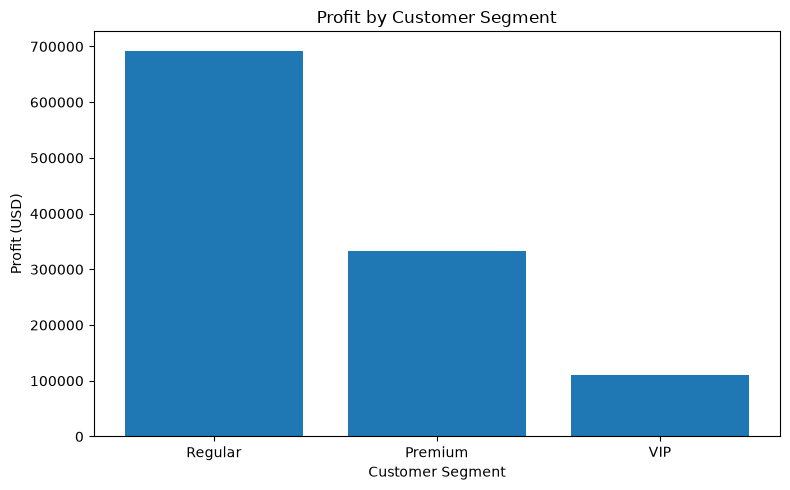

In [72]:
plt.figure(figsize=(8,5))

plt.bar(
    segment_profit.index,
    segment_profit.values
)

plt.title("Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Profit (USD)")

plt.tight_layout()
plt.savefig("../images/segment_profit.png")
plt.show()

### Profit by Customer Segment

The profit contribution closely mirrors the revenue distribution across customer segments.

Regular customers generated the highest profit, indicating that this segment is both the largest revenue contributor and the most financially valuable customer group.

```Which age group spends the most?```

**check the age distribution**

In [82]:
completed_orders["age"].describe()

count   6,986.00
mean       46.40
std        16.83
min        18.00
25%        32.00
50%        46.00
75%        61.00
max        75.00
Name: age, dtype: float64

**create age groups**

In [79]:
completed_orders["age_group"] = pd.cut(
    completed_orders["age"],
    bins=[18,25,35,45,55,65,100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ]
)

In [83]:
age_revenue = (
    completed_orders
    .groupby("age_group")["total_price_usd"]
    .sum()
    .sort_values(ascending=False)
)

age_revenue

age_group
65+     512,572.40
36-45   494,018.63
56-65   486,118.66
46-55   477,124.06
26-35   463,701.49
18-25   358,813.73
Name: total_price_usd, dtype: float64

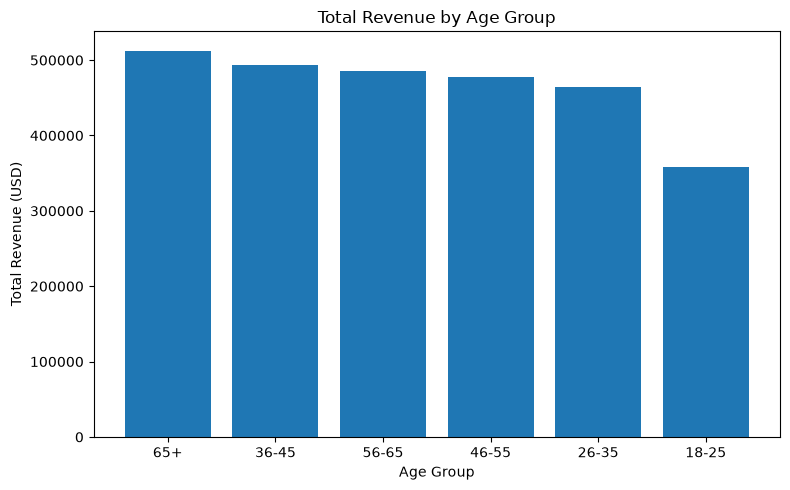

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(
    age_revenue.index,
    age_revenue.values
)

plt.title("Total Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Revenue (USD)")

plt.tight_layout()
plt.savefig("../images/age_revenue.png")
plt.show()

### Revenue by Age Group

Customers aged 65 and above generated the highest total revenue, while the 18–25 age group contributed the least.

This suggests that older customers in the dataset tend to make higher-value purchases or purchase more frequently than younger customers. Marketing strategies could be tailored differently for each age segment.

```Which gender generates the highest revenue?```


In [87]:
gender_revenue = (
    completed_orders
    .groupby("gender")["total_price_usd"]
    .sum()
    .sort_values(ascending=False)
)

gender_revenue

gender
Male     1,437,273.51
Female   1,409,965.61
Name: total_price_usd, dtype: float64

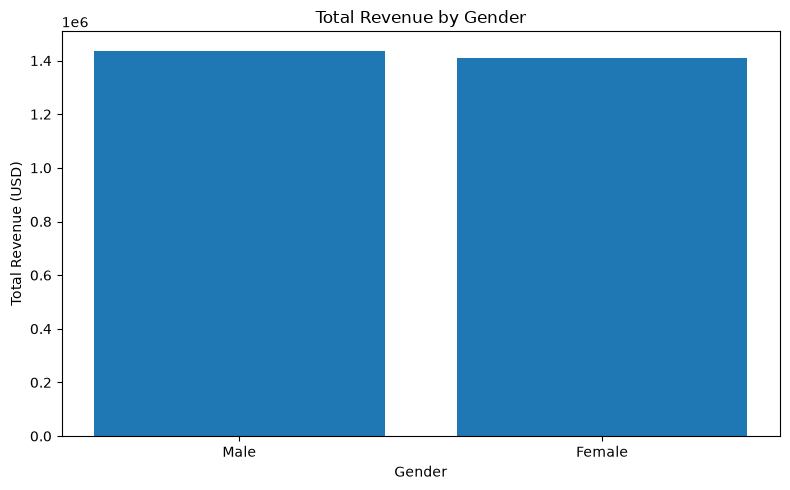

In [88]:
plt.figure(figsize=(8,5))
plt.bar(
    gender_revenue.index,
    gender_revenue.values
)
plt.title("Total Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue (USD)")

plt.tight_layout()
plt.savefig("../images/gender_revenue.png")
plt.show()

### Revenue by Gender

Revenue generated by male and female customers was nearly identical throughout the analysis period.

This indicates a balanced customer base, with no significant revenue dependence on a particular gender.

```Which loyalty level generates the highest revenue?```


In [91]:
loyalty_revenue = (
    completed_orders
    .groupby("customer_loyalty_score")["total_price_usd"]
    .sum()
    .sort_values(ascending=False)
)

loyalty_revenue

customer_loyalty_score
83.90   9,200.65
47.40   8,454.44
2.10    8,042.65
89.40   7,901.41
33.70   7,754.15
          ...   
51.20     253.59
63.30     247.75
22.20     212.01
36.50     140.52
17.60      90.99
Name: total_price_usd, Length: 1000, dtype: float64

```Which payment method is used most?```

In [92]:
completed_orders["payment_method"].value_counts()

payment_method
Debit Card       1452
Apple Pay        1446
PayPal           1375
Credit Card      1365
Bank Transfer    1348
Name: count, dtype: int64

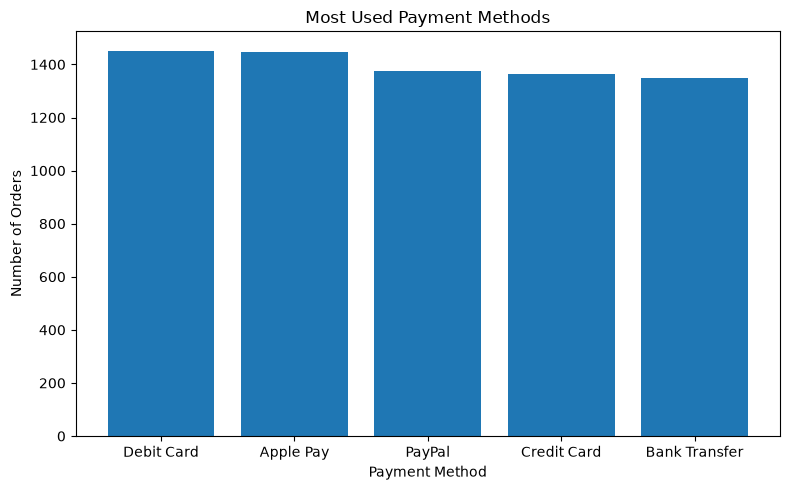

In [94]:
payment_counts = completed_orders["payment_method"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    payment_counts.index,
    payment_counts.values
)

plt.title("Most Used Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.savefig("../images/payment_methods.png")
plt.show()

### Payment Method Usage

All payment methods showed similar usage frequencies, with Debit Card and Apple Pay being slightly more popular than the others.

The relatively balanced distribution suggests that customers actively use multiple payment options. Maintaining support for all major payment methods is important for ensuring a smooth checkout experience.

```Which payment method generates the highest revenue?```


In [95]:
payment_revenue = (
    completed_orders
    .groupby("payment_method")["total_price_usd"]
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

payment_method
Debit Card      596,832.33
Apple Pay       592,475.97
PayPal          559,737.37
Credit Card     556,372.38
Bank Transfer   541,821.07
Name: total_price_usd, dtype: float64

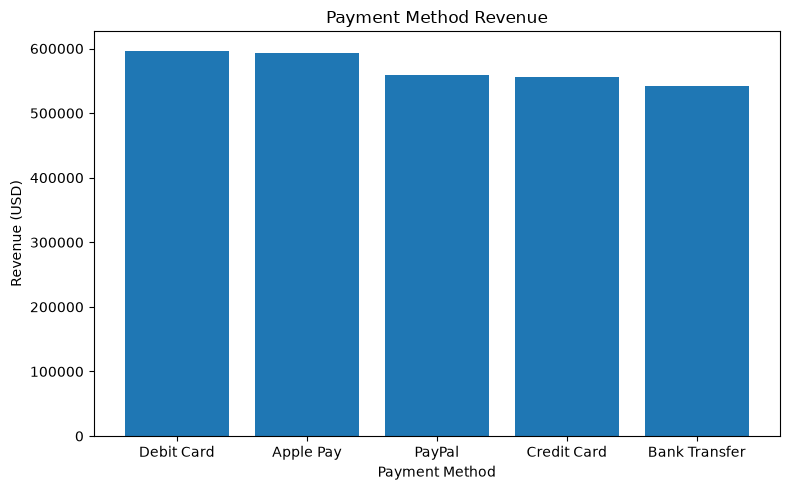

In [96]:
plt.figure(figsize=(8,5))
plt.bar(
    payment_revenue.index,
    payment_revenue.values
)
plt.title("Payment Method Revenue")
plt.xlabel("Payment Method")
plt.ylabel("Revenue (USD)")
plt.tight_layout()
plt.savefig("../images/payment_revenue.png")
plt.show()


### Revenue by Payment Method

Revenue generated by each payment method was relatively balanced across the business.

No single payment option dominated sales performance, indicating that customers are comfortable using different payment methods when making purchases.

In [97]:
customer_summary = (
    completed_orders
    .groupby("customer_segment")
    .agg(
        Revenue=("total_price_usd","sum"),
        Profit=("profit_usd","sum"),
        Orders=("order_id","count"),
        Average_Order_Value=("total_price_usd","mean"),
        Average_Rating=("rating","mean")
    )
)

customer_summary

,Revenue,Profit,Orders,Average_Order_Value,Average_Rating
customer_segment,,,,,
Premium,"839,406.39","333,505.54",2071,405.31,2.98
Regular,"1,730,983.10","692,494.97",4238,408.44,2.98
VIP,"276,849.63","110,467.78",677,408.94,3.03


## Customer Analysis Summary

Regular customers contributed the largest share of both revenue and profit, highlighting the importance of customer retention strategies for this segment.

Revenue was distributed fairly evenly across genders and payment methods, suggesting a balanced customer base and diverse purchasing preferences.

Older customer groups generated higher total revenue, while younger customers contributed comparatively less. Future analyses could investigate whether this difference is driven by customer volume or average spending per customer.

```Average Order Value by Customer Segment```

In [98]:
segment_aov = (
    completed_orders
    .groupby("customer_segment")["total_price_usd"]
    .mean()
    .sort_values(ascending=False)
)

segment_aov

customer_segment
VIP       408.94
Regular   408.44
Premium   405.31
Name: total_price_usd, dtype: float64

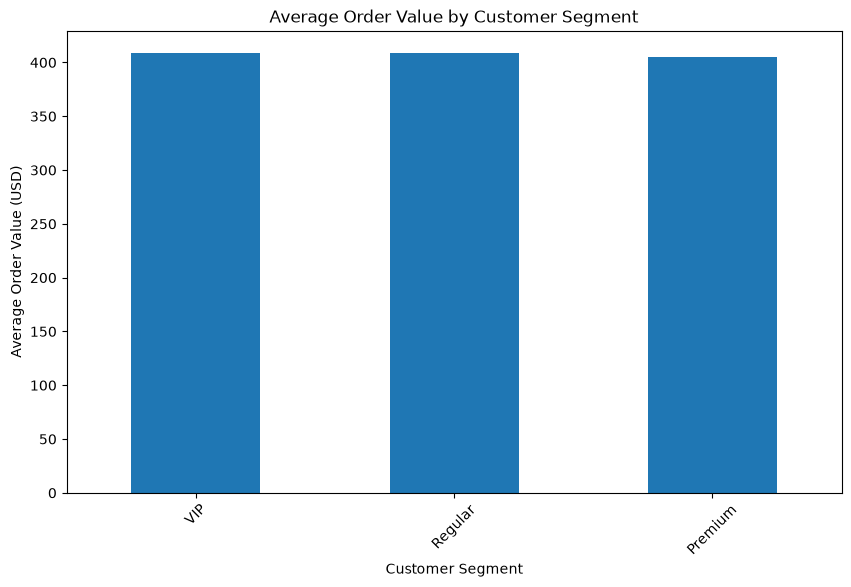

In [101]:
plt.figure(figsize=(10, 6))
segment_aov.plot(kind="bar")
plt.title("Average Order Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Order Value (USD)")
plt.xticks(rotation=45)
plt.savefig("../images/segment_aov.png")
plt.show()